# Loading a gridded/raster dataset from a netcdf file
This notebook demonstrates how to use the Azure Data Asset concept to access gridded/raster weather and climate data stored in netcdf files and load it into an xarray dataset.

### Load the libraries
In this example we will use the Azure SDK v2 together with azureml-fsspec and xarray.

In [20]:
import pathlib
import datetime

In [2]:
import xarray

In [3]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential


### Mount the data asset in the local posix file system
Unlike the tabular data which one can load directly through the Azure SDK, with a Netcdf file, we need to moutn the data asset so we can directly access the data through the `xarray.open_dataset` function.

In [4]:
ml_client = MLClient.from_config(credential=DefaultAzureCredential())
data_asset = ml_client.data.get("weatherbench5625", version="1")


Found the config file in: /config.json


In [5]:
print(data_asset.path)

azureml://subscriptions/9734ed68-621d-47ed-babd-269110dbacb1/resourcegroups/1-3ebf4564-playground-sandbox/workspaces/dscoptest1/datastores/workspaceartifactstore/paths/weatherbench/5.625deg/


In [13]:
weatherbench_mount_path = pathlib.Path.home() / 'wb2'
weatherbench_mount_path

PosixPath('/home/azureuser/wb2')

In [14]:
# ml_client.datastores.mount(
#     'azureml://subscriptions/9734ed68-621d-47ed-babd-269110dbacb1/resourcegroups/1-3ebf4564-playground-sandbox/workspaces/dscoptest1/datastores/workspaceartifactstore',
#     mount_point=str(weatherbench_mount_path)
# )

In [15]:
ml_client.data.mount(
    data_asset.path,
    mount_point=str(weatherbench_mount_path)
)

Resolving credential...
trying to get token from DefaultAzureCredential
resolved DefaultAzureCredential to ManagedIdentityCredential
resolved ManagedIdentityCredential to AzureMLCredential
trying to get token from AzureMLCredential
Resolved credential.
Mount starting...
Subprocess PID: 102436
Mount started successfully.
To unmount, run `$ umount /home/azureuser/wb2`.
Logs can be found at /tmp/azureml-logs/dataprep/rslex-fuse-cli


In [37]:
!ls /home/azureuser/wb2

Exception ignored in: <function PeriodicExportingMetricReader.__init__.<locals>.<lambda> at 0x7fd51e835580>
Traceback (most recent call last):
  File "/anaconda/envs/dscop_pytorch/lib/python3.12/site-packages/opentelemetry/sdk/metrics/_internal/export/__init__.py", line 535, in <lambda>
    after_in_child=lambda: weak_at_fork()()  # pylint: disable=unnecessary-lambda
                           ^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not callable


2m_temperature_1979_5.625deg.nc  2m_temperature_1999_5.625deg.nc
2m_temperature_1980_5.625deg.nc  2m_temperature_2000_5.625deg.nc
2m_temperature_1981_5.625deg.nc  2m_temperature_2001_5.625deg.nc
2m_temperature_1982_5.625deg.nc  2m_temperature_2002_5.625deg.nc
2m_temperature_1983_5.625deg.nc  2m_temperature_2003_5.625deg.nc
2m_temperature_1984_5.625deg.nc  2m_temperature_2004_5.625deg.nc
2m_temperature_1985_5.625deg.nc  2m_temperature_2005_5.625deg.nc
2m_temperature_1986_5.625deg.nc  2m_temperature_2006_5.625deg.nc
2m_temperature_1987_5.625deg.nc  2m_temperature_2007_5.625deg.nc
2m_temperature_1988_5.625deg.nc  2m_temperature_2008_5.625deg.nc
2m_temperature_1989_5.625deg.nc  2m_temperature_2009_5.625deg.nc
2m_temperature_1990_5.625deg.nc  2m_temperature_2010_5.625deg.nc
2m_temperature_1991_5.625deg.nc  2m_temperature_2011_5.625deg.nc
2m_temperature_1992_5.625deg.nc  2m_temperature_2012_5.625deg.nc
2m_temperature_1993_5.625deg.nc  2m_temperature_2013_5.625deg.nc
2m_temperature_1994_5.625

We can now see that the files are mounted like local files.`

### Load the data into xarray and plot
We can now load and plot the data as we would on any other platform.

In [31]:
[p1 for p1 in weatherbench_mount_path.iterdir() if '2010' in str(p1)][0]

PosixPath('/home/azureuser/wb2/2m_temperature_2010_5.625deg.nc')

In [33]:
wb_ds = xarray.open_dataset([p1 for p1 in weatherbench_mount_path.iterdir() if '2010' in str(p1)][0])

In [34]:
wb_ds

<xarray.Dataset> Size: 72MB
Dimensions:  (time: 8760, lat: 32, lon: 64)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2010-01-01 ... 2010-12-31T23:00:00
  * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    t2m      (time, lat, lon) float32 72MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2019-11-07 14:14:00 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...

Matplotlib is building the font cache; this may take a moment.


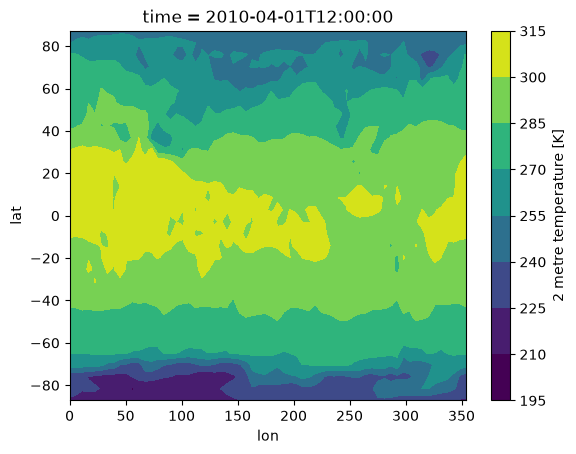

In [36]:
wb_ds.sel(time=datetime.datetime(2010,4,1,12,0))['t2m'].plot.contourf()